In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [15]:
df = pd.read_parquet('./dataset.parquet')


df.columns


Index(['mean_intensity_C0_nuc', 'mean_intensity_C1_nuc', 'label', 'x', 'y',
       'area', 'median_intensity_C0_nuc', 'median_intensity_C1_nuc',
       'mean_intensity_C0_ring', 'mean_intensity_C1_ring',
       'median_intensity_C0_ring', 'median_intensity_C1_ring', 'cnr',
       'cnr_median', 'particle', 'fov', 'fov_x', 'fov_y', 'fov_name',
       'timestep', 'time', 'cell_line', 'channels', 'fname', 'optocheck',
       'optocheck_channels', 'ramp_pattern_name', 'stim_timestep',
       'stim_exposure_list', 'stim_power', 'stim_channel_name',
       'stim_channel_group', 'stim_channel_device_name',
       'stim_channel_power_property_name', 'stim_exposure', 'stim',
       'optocheck_mean_intensity', 'frame', 'cnr_median_norm', 'cnr_mean_norm',
       'median_cnr_0_9', 'energy_uJ', 'fluence_mJ_cm2', 'energy_per_cell',
       'u_t', 'm_t', 'recency', 'burst_pos', 'n_5', 'slope_5', 'uid',
       'ewma_fast', 'ewma_slow', 's_cum'],
      dtype='object')

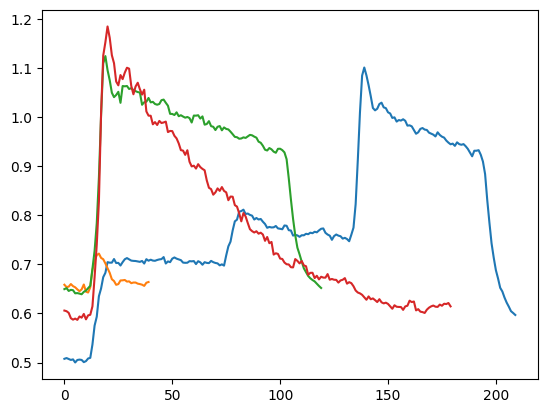

In [31]:
metr = 'cnr_median'
# fit on medians
pltbl = df.groupby(['ramp_pattern_name', 'frame'])[metr].median().reset_index().sort_values(['ramp_pattern_name', 'frame'])
for rpn in pltbl['ramp_pattern_name'].unique():
  p = pltbl[pltbl['ramp_pattern_name'] == rpn]
  plt.plot(p['frame'], p[metr])

Fitting cells: 100%|████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:23<00:00,  1.19s/it]


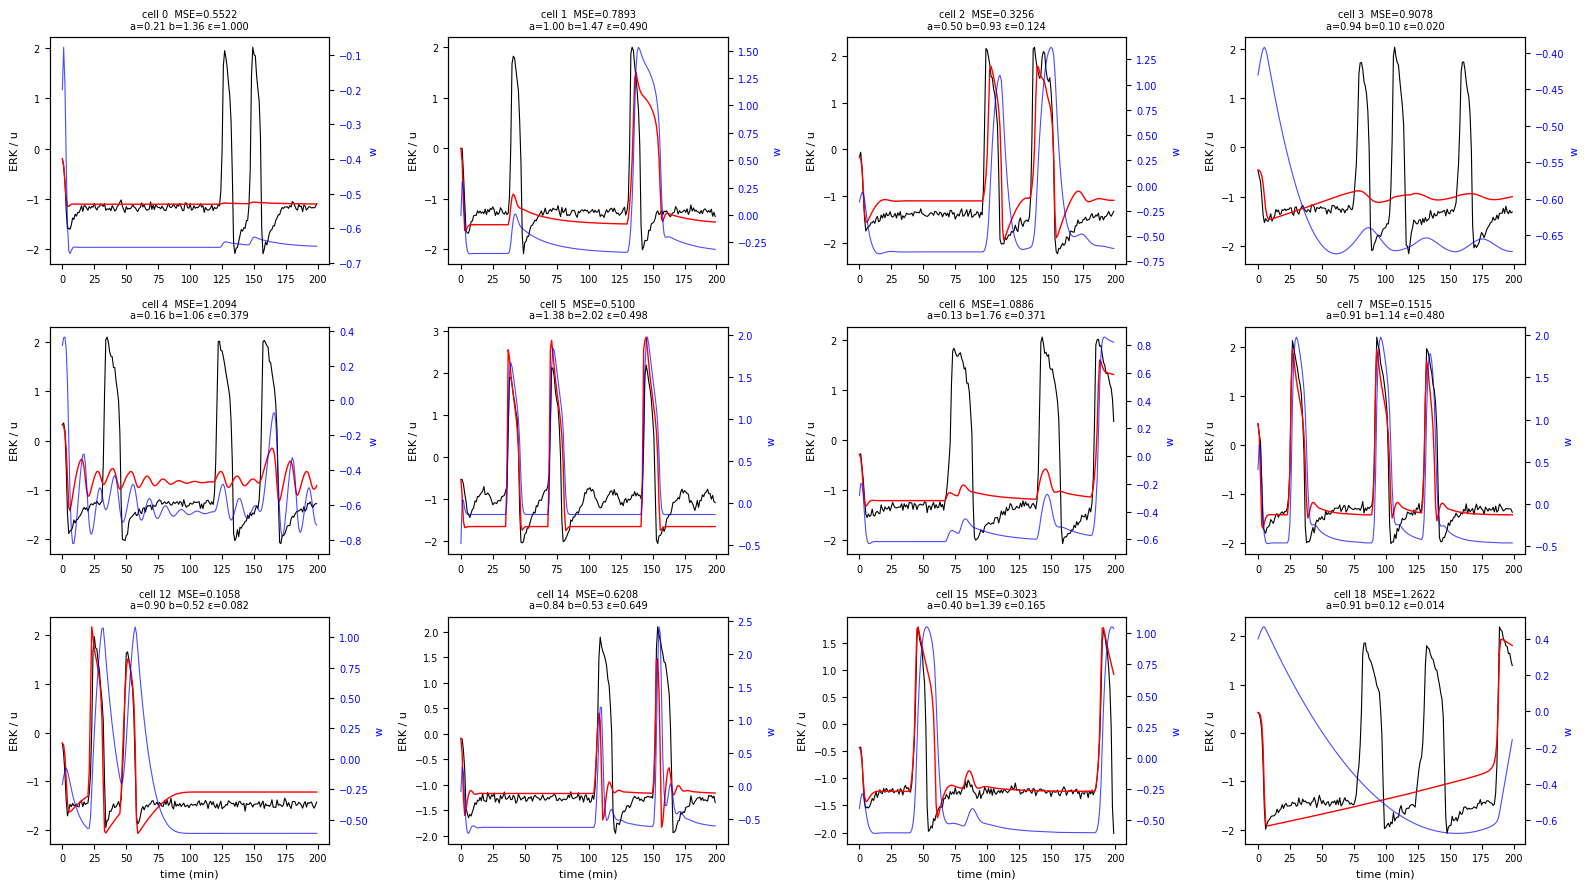

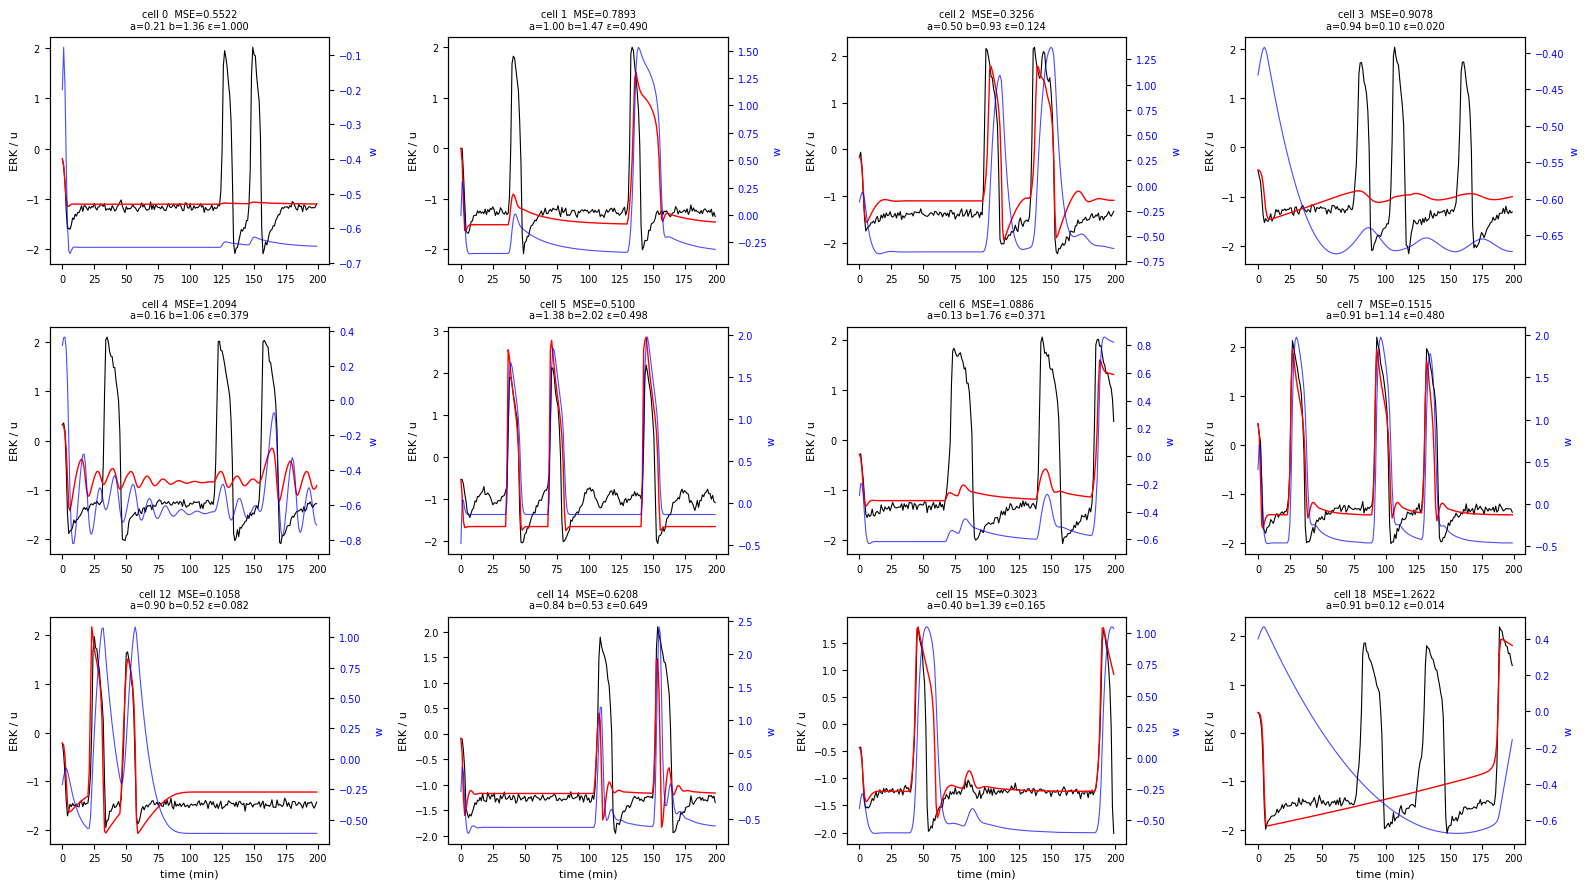

In [38]:
from ode_fit import fit_all_cells, extract_state_matrix, plot_fits, _generate_synthetic_data, plot_fit_quality, plot_parameter_distributions

erk_data, stim_data, tpl = _generate_synthetic_data()

results = fit_all_cells(erk_data, stim_data, n_restarts=5)
state_matrix = extract_state_matrix(results)
fig = plot_fits(results, erk_data)
fig


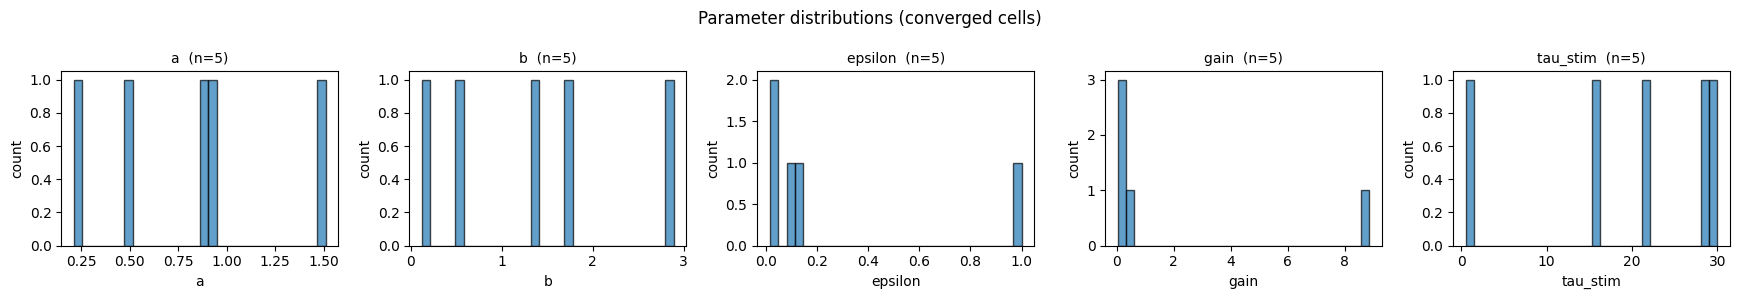

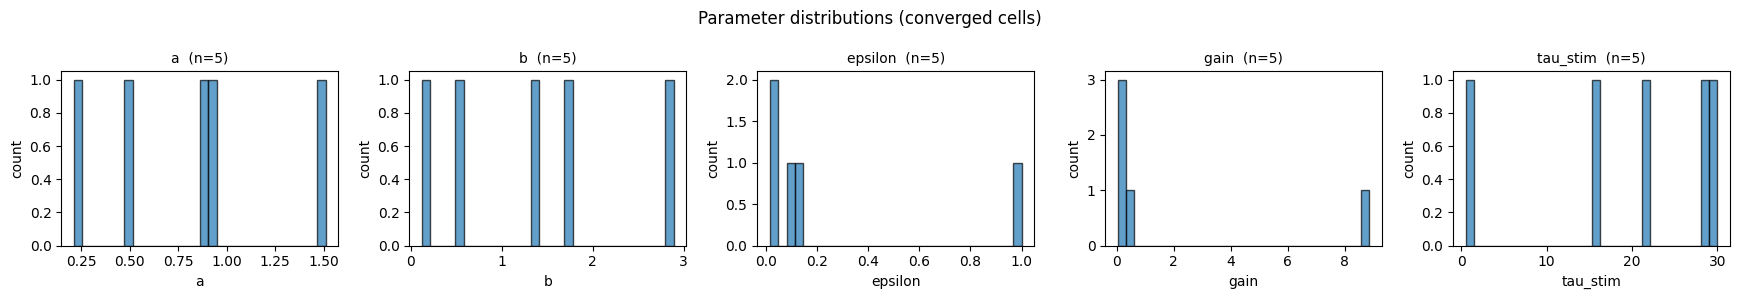

In [39]:
plot_parameter_distributions(results)

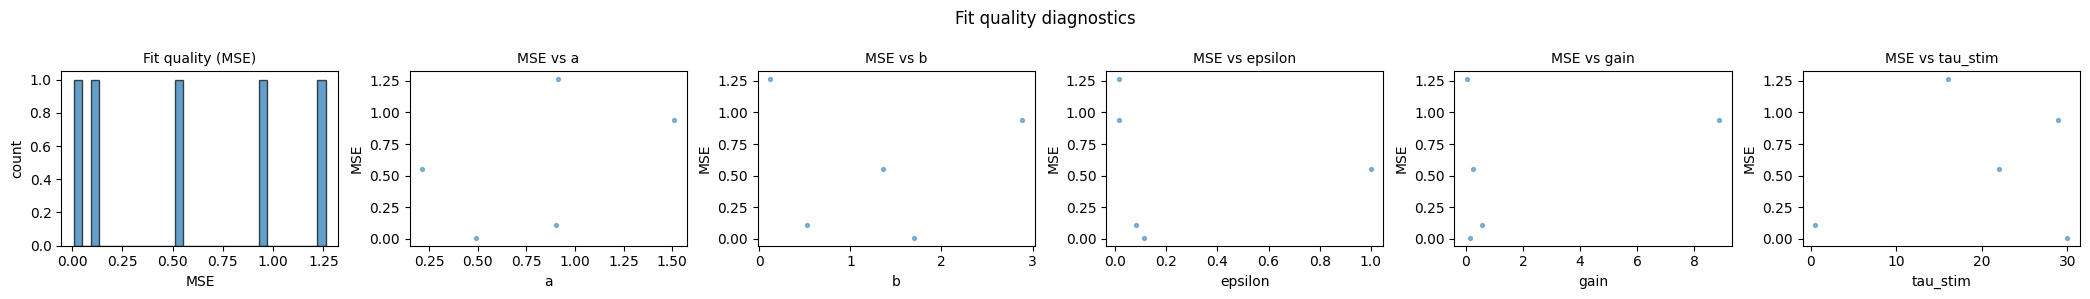

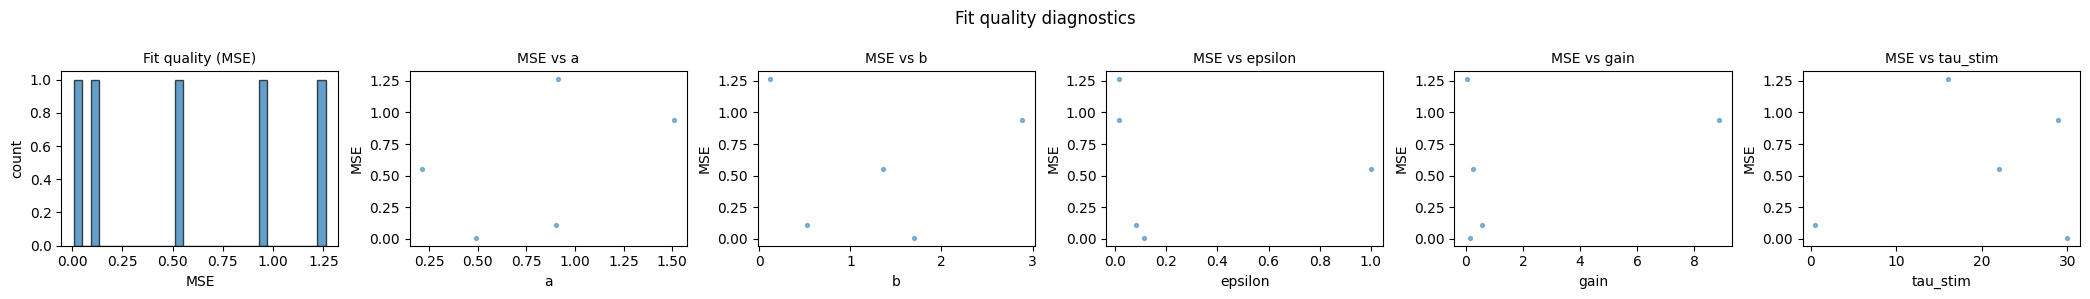

In [40]:
plot_fit_quality(results)

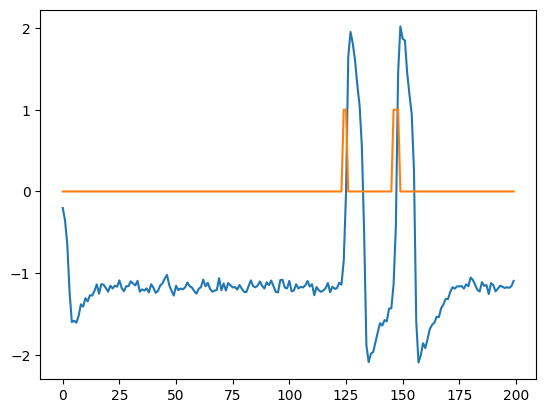

In [41]:
plt.plot(np.arange(erk_data.shape[1]), erk_data[0])
plt.plot(np.arange(erk_data.shape[1]), stim_data[0])

In [42]:
import ode_fit

In [ ]:
ode_fit._integrate_fhn()